## Objective
This project analyzes the Divvy Bikes trip dataset to understand user behavior, ride patterns, station popularity, and seasonal trends.

The analysis focuses on:
- Casual vs Member rider behavior
- Trip duration patterns
- Peak ride timings
- Popular stations and routes
- Monthly and weekly usage trends
- Business insights and recommendations

In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

In [4]:
df = pd.read_csv("202404-divvy-tripdata.csv")
df.head()

,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual
0,743252713F32516B,classic_bike,2024-04-22 19:08:21,2024-04-22 19:12:56,Aberdeen St & Jackson Blvd,13157,Desplaines St & Jackson Blvd,15539,41.877726,-87.654787,41.878119,-87.643948,member
1,BE90D33D2240C614,electric_bike,2024-04-11 06:19:24,2024-04-11 06:22:21,Aberdeen St & Jackson Blvd,13157,Desplaines St & Jackson Blvd,15539,41.877722,-87.654959,41.878119,-87.643948,member
2,D47BBDDE7C40DD61,classic_bike,2024-04-20 11:13:13,2024-04-20 11:29:31,Sheridan Rd & Montrose Ave,TA1307000107,Ashland Ave & Belle Plaine Ave,13249,41.961670,-87.654640,41.956057,-87.668835,member
3,6684E760BF9EA9B5,classic_bike,2024-04-04 18:39:20,2024-04-04 18:43:06,Aberdeen St & Jackson Blvd,13157,Desplaines St & Jackson Blvd,15539,41.877726,-87.654787,41.878119,-87.643948,member
4,CA9EFC0D24C24A27,electric_bike,2024-04-19 19:30:20,2024-04-19 20:07:42,Sheridan Rd & Montrose Ave,TA1307000107,Stetson Ave & South Water St,TA1308000029,41.961613,-87.654615,41.886835,-87.622320,member


In [15]:
df.shape

(415025, 13)

In [16]:
df.columns

Index(['ride_id', 'rideable_type', 'started_at', 'ended_at',
       'start_station_name', 'start_station_id', 'end_station_name',
       'end_station_id', 'start_lat', 'start_lng', 'end_lat', 'end_lng',
       'member_casual'],
      dtype='object')

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 415025 entries, 0 to 415024
Data columns (total 13 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   ride_id             415025 non-null  object 
 1   rideable_type       415025 non-null  object 
 2   started_at          415025 non-null  object 
 3   ended_at            415025 non-null  object 
 4   start_station_name  340232 non-null  object 
 5   start_station_id    340232 non-null  object 
 6   end_station_name    336506 non-null  object 
 7   end_station_id      336506 non-null  object 
 8   start_lat           415025 non-null  float64
 9   start_lng           415025 non-null  float64
 10  end_lat             414546 non-null  float64
 11  end_lng             414546 non-null  float64
 12  member_casual       415025 non-null  object 
dtypes: float64(4), object(9)
memory usage: 41.2+ MB


In [18]:
df.describe()

,start_lat,start_lng,end_lat,end_lng
count,415025.000000,415025.000000,414546.000000,414546.000000
mean,41.900646,-87.646073,41.901147,-87.646311
std,0.047518,0.027988,0.047667,0.028039
min,41.648501,-87.890000,41.648501,-87.960000
25%,41.880000,-87.660000,41.880000,-87.660000
50%,41.896644,-87.642884,41.896945,-87.643118
75%,41.930000,-87.629318,41.930000,-87.629521
max,42.070000,-87.528232,42.150000,-87.528232


In [19]:
df.isnull().sum()

ride_id                   0
rideable_type             0
started_at                0
ended_at                  0
start_station_name    74793
start_station_id      74793
end_station_name      78519
end_station_id        78519
start_lat                 0
start_lng                 0
end_lat                 479
end_lng                 479
member_casual             0
dtype: int64

In [20]:
df.duplicated().sum()

np.int64(0)

##### Observation:
* Dataset has 415,025 rows and 13 columns.
* Missing values exist in:
    * start_station_name
    * start_station_id
    * end_station_name
    * end_station_id
    * end_lat
    * end_lng
* No duplicate rows
* started_at and ended_at are object datatype → should be converted to datetime

In [21]:
df = df.dropna(subset=['start_station_name', 'end_station_name'])

 Removing rows with missing start and end station names
 because station information is essential for route and station analysis.
 Only specific columns were considered to avoid unnecessary data loss.

In [22]:
df['started_at'] = pd.to_datetime(df['started_at'])
df['ended_at'] = pd.to_datetime(df['ended_at'])

### Data Cleaning Summary
- Removed rows with missing station names
- Converted date columns into datetime format
- Created trip duration feature
- Removed invalid trips with negative or zero duration

In [23]:
df.info() # cheching again

<class 'pandas.core.frame.DataFrame'>
Index: 297798 entries, 0 to 415021
Data columns (total 13 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   ride_id             297798 non-null  object        
 1   rideable_type       297798 non-null  object        
 2   started_at          297798 non-null  datetime64[ns]
 3   ended_at            297798 non-null  datetime64[ns]
 4   start_station_name  297798 non-null  object        
 5   start_station_id    297798 non-null  object        
 6   end_station_name    297798 non-null  object        
 7   end_station_id      297798 non-null  object        
 8   start_lat           297798 non-null  float64       
 9   start_lng           297798 non-null  float64       
 10  end_lat             297798 non-null  float64       
 11  end_lng             297798 non-null  float64       
 12  member_casual       297798 non-null  object        
dtypes: datetime64[ns](2), float64(4), 

In [24]:
df['trip_duration'] = (df['ended_at'] - df['started_at']).dt.total_seconds()/60

In [25]:
df = df[df['trip_duration'] > 0]
df = df[df['trip_duration'] <= 1440] # 1440 = 24 hrs

### SECTION 1
1. What is the overall profile of Divvy users?

In [26]:
(df['member_casual'].value_counts(normalize=True)*100)

member_casual
member    68.455118
casual    31.544882
Name: proportion, dtype: float64

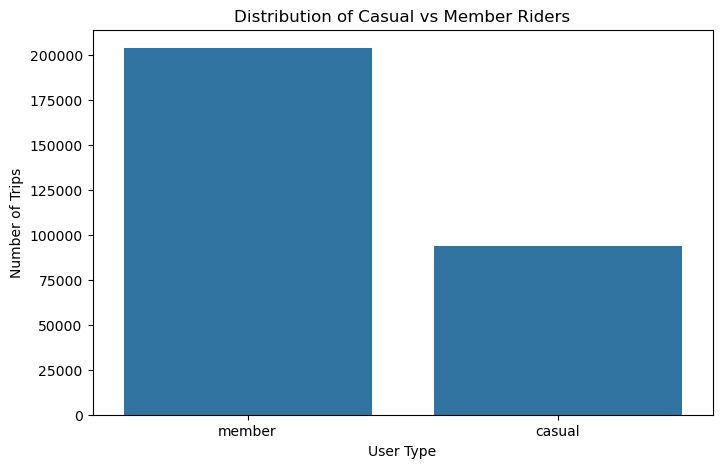

In [27]:
plt.figure(figsize=(8,5))
sns.countplot(x='member_casual', data=df)
plt.title('Distribution of Casual vs Member Riders')
plt.xlabel('User Type')
plt.ylabel('Number of Trips')
plt.show()

### Interpretation
- Members contribute the majority of rides.
- Classic bikes are the most used rideable type.
- Casual riders also form a significant portion of users.
- Electric bikes are becoming increasingly popular.

In [28]:
df['rideable_type'].value_counts()

rideable_type
classic_bike     187870
electric_bike    109855
Name: count, dtype: int64

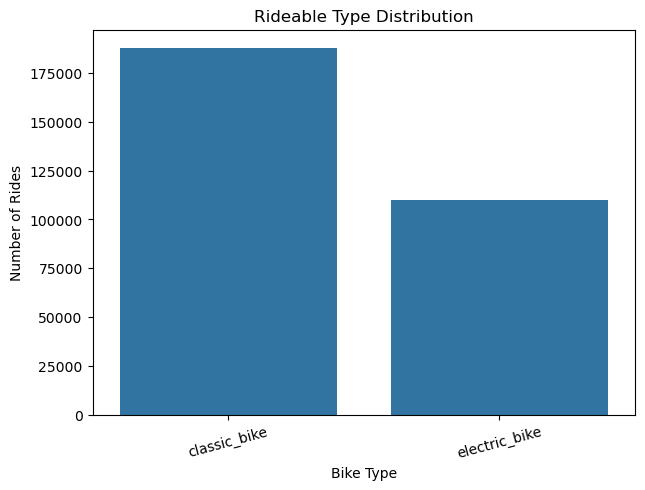

In [29]:
plt.figure(figsize=(7,5))

sns.countplot(
    x='rideable_type',
    data=df
)

plt.title('Rideable Type Distribution')
plt.xlabel('Bike Type')
plt.ylabel('Number of Rides')

plt.xticks(rotation=15)

plt.show()

#### QUESTION 2
How long are typical trips?
What is the distribution of trip durations?
Are there many unusually long or short trips?

In [30]:
df['trip_duration'].describe()

count    297725.000000
mean         16.148378
std          33.820280
min           0.016667
25%           5.516667
50%           9.750000
75%          17.866667
max        1437.616667
Name: trip_duration, dtype: float64

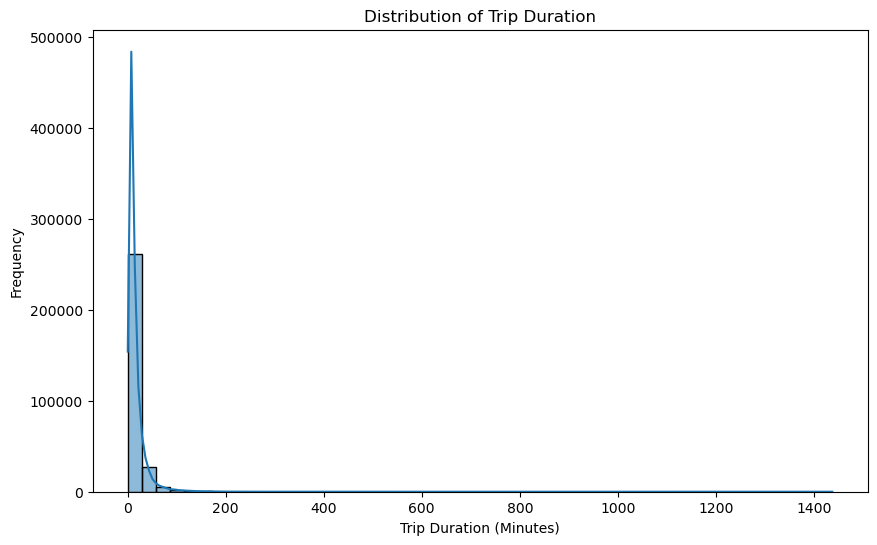

In [31]:
plt.figure(figsize=(10,6))

sns.histplot(
    df['trip_duration'],
    bins=50,
    kde=True
)

plt.title('Distribution of Trip Duration')
plt.xlabel('Trip Duration (Minutes)')
plt.ylabel('Frequency')

plt.show()

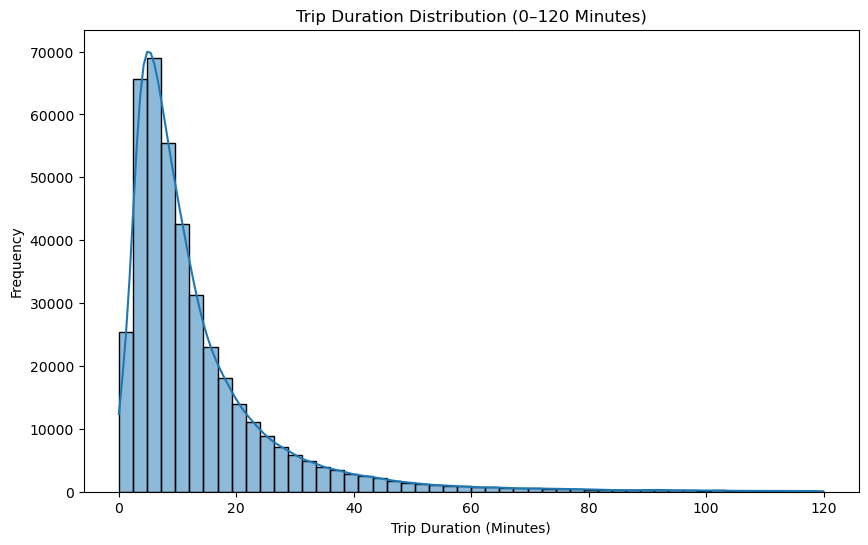

In [42]:
plt.figure(figsize=(10,6))

sns.histplot(
    df[df['trip_duration'] <= 120]['trip_duration'],
    bins=50,
    kde=True
)

plt.title('Trip Duration Distribution (0–120 Minutes)')
plt.xlabel('Trip Duration (Minutes)')
plt.ylabel('Frequency')

plt.show() # for better visibility

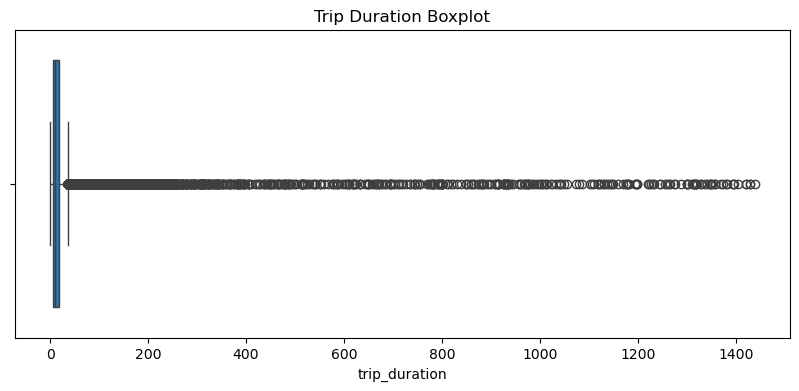

In [32]:
plt.figure(figsize=(10,4))

sns.boxplot(
    x=df['trip_duration']
)

plt.title('Trip Duration Boxplot')

plt.show()

### Interpretation
- Most trips are short in duration.
- The distribution is right-skewed.
- Some unusually long trips exist as outliers.
- Casual riders generally take longer rides.

#### QUESTION - 3
Which stations are the most popular (start and end stations)?
Are the busiest stations the same for start and end?

In [33]:
top_start = df['start_station_name'].value_counts().head(10)

top_start

start_station_name
Streeter Dr & Grand Ave              4107
DuSable Lake Shore Dr & Monroe St    3023
Clinton St & Washington Blvd         2524
University Ave & 57th St             2522
Kingsbury St & Kinzie St             2374
Clark St & Elm St                    2178
Michigan Ave & Oak St                2169
Clinton St & Madison St              2125
Ellis Ave & 60th St                  2119
Millennium Park                      1946
Name: count, dtype: int64

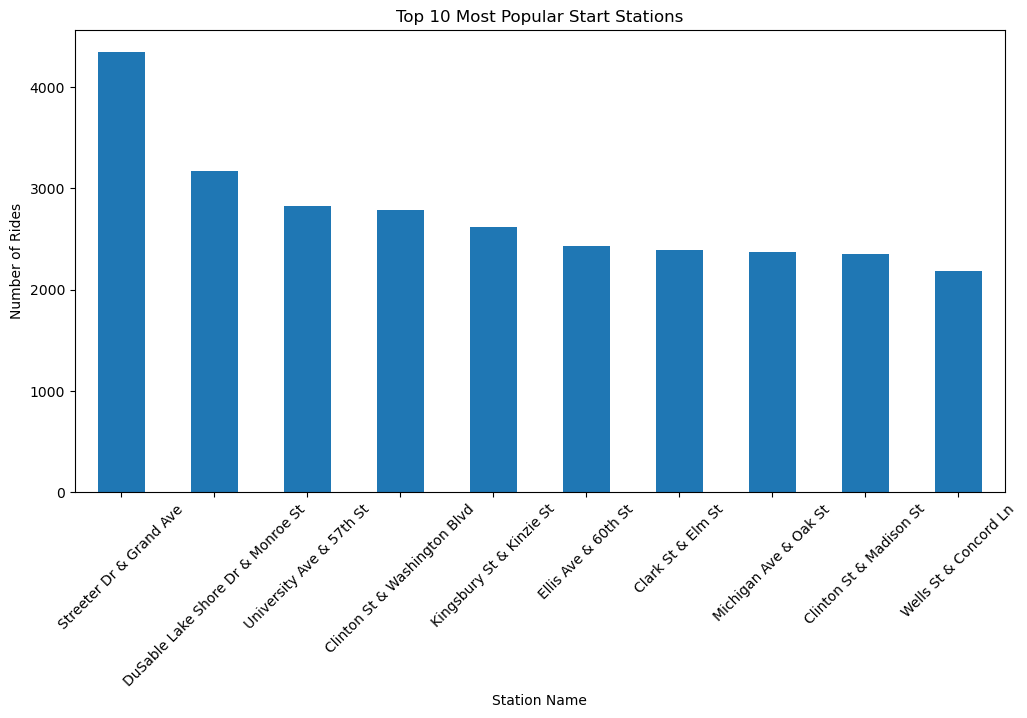

In [47]:
plt.figure(figsize=(12,6))

top_start.plot(kind='bar')

plt.title('Top 10 Most Popular Start Stations')
plt.xlabel('Station Name')
plt.ylabel('Number of Rides')

plt.xticks(rotation=45)

plt.show()

In [34]:
top_end = df['end_station_name'].value_counts().head(10)

top_end

end_station_name
Streeter Dr & Grand Ave              4117
DuSable Lake Shore Dr & Monroe St    2909
Clinton St & Washington Blvd         2539
University Ave & 57th St             2483
Kingsbury St & Kinzie St             2354
Michigan Ave & Oak St                2184
Ellis Ave & 60th St                  2154
Clinton St & Madison St              2123
Clark St & Elm St                    2101
Millennium Park                      1941
Name: count, dtype: int64

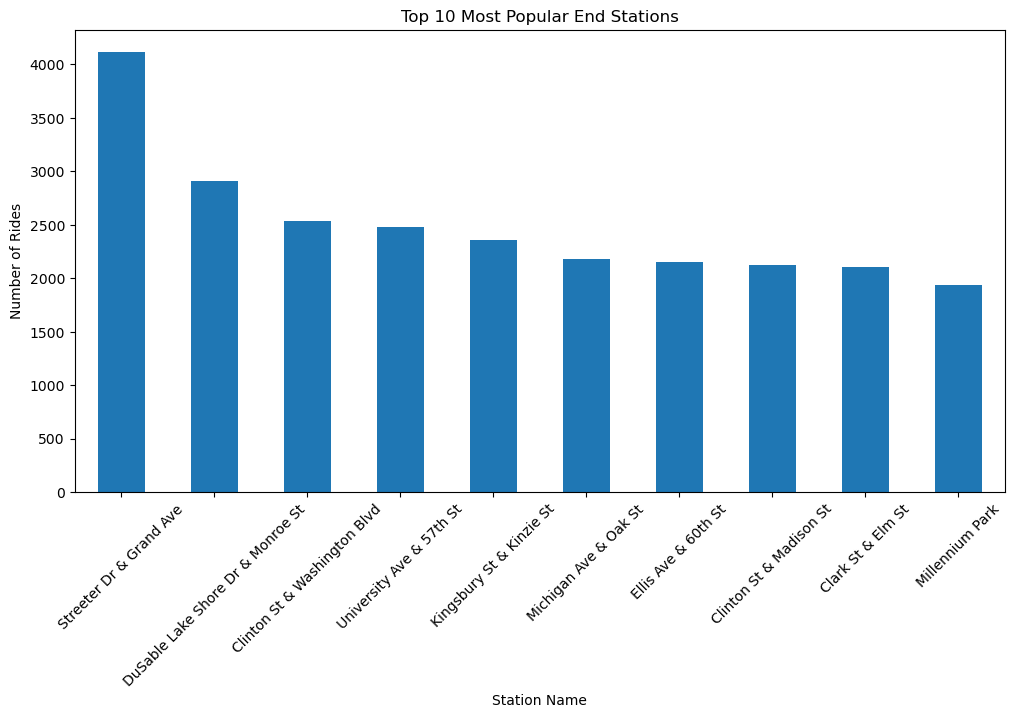

In [35]:
plt.figure(figsize=(12,6))

top_end.plot(kind='bar')

plt.title('Top 10 Most Popular End Stations')
plt.xlabel('Station Name')
plt.ylabel('Number of Rides')

plt.xticks(rotation=45)

plt.show()

In [36]:
print("Top Start Stations")
print(top_start.index)

print("\nTop End Stations")
print(top_end.index)

Top Start Stations
Index(['Streeter Dr & Grand Ave', 'DuSable Lake Shore Dr & Monroe St',
       'Clinton St & Washington Blvd', 'University Ave & 57th St',
       'Kingsbury St & Kinzie St', 'Clark St & Elm St',
       'Michigan Ave & Oak St', 'Clinton St & Madison St',
       'Ellis Ave & 60th St', 'Millennium Park'],
      dtype='object', name='start_station_name')

Top End Stations
Index(['Streeter Dr & Grand Ave', 'DuSable Lake Shore Dr & Monroe St',
       'Clinton St & Washington Blvd', 'University Ave & 57th St',
       'Kingsbury St & Kinzie St', 'Michigan Ave & Oak St',
       'Ellis Ave & 60th St', 'Clinton St & Madison St', 'Clark St & Elm St',
       'Millennium Park'],
      dtype='object', name='end_station_name')


### Interpretation
- Some stations consistently act as major hubs.
- Popular stations are usually located in commercial or tourist areas.
- Start and end stations show similar traffic patterns.

### SECTION 2
How do Casual riders and Annual Members differ in their behavior? Analyze at least: - Trip duration - Trip frequency by day of week and hour of day - Preferred rideable type (classic, electric, docked) - Popular stations/routes

In [37]:
df['day_of_week'] = df['started_at'].dt.day_name()

df['hour'] = df['started_at'].dt.hour

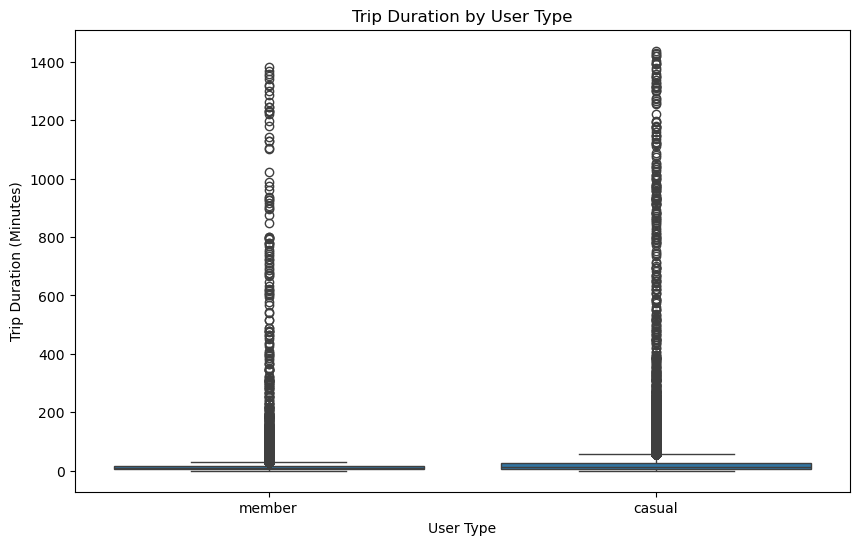

In [38]:
plt.figure(figsize=(10,6))

sns.boxplot(
    x='member_casual',
    y='trip_duration',
    data=df
)

plt.title('Trip Duration by User Type')
plt.xlabel('User Type')
plt.ylabel('Trip Duration (Minutes)')

plt.show()

### Interpretation
- Casual riders take longer trips.
- Members usually take shorter trips for commuting.

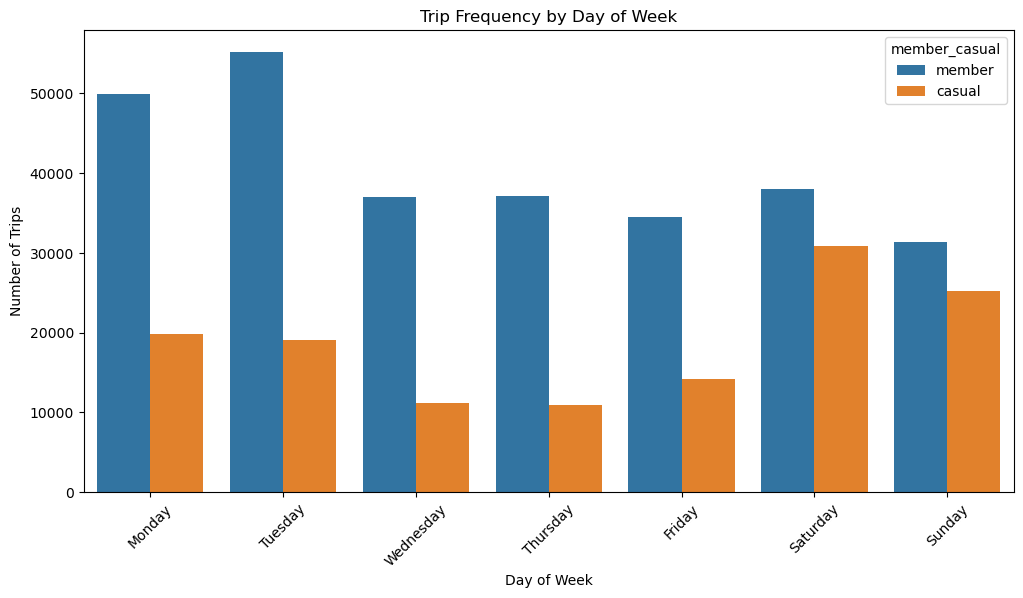

In [53]:
plt.figure(figsize=(12,6))

sns.countplot(
    x='day_of_week',
    hue='member_casual',
    data=df,
    order=[
        'Monday','Tuesday','Wednesday',
        'Thursday','Friday',
        'Saturday','Sunday'
    ]
)

plt.title('Trip Frequency by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Number of Trips')

plt.xticks(rotation=45)

plt.show()

### Interpretation
- Members are more active during weekdays.
- Casual riders increase during weekends.

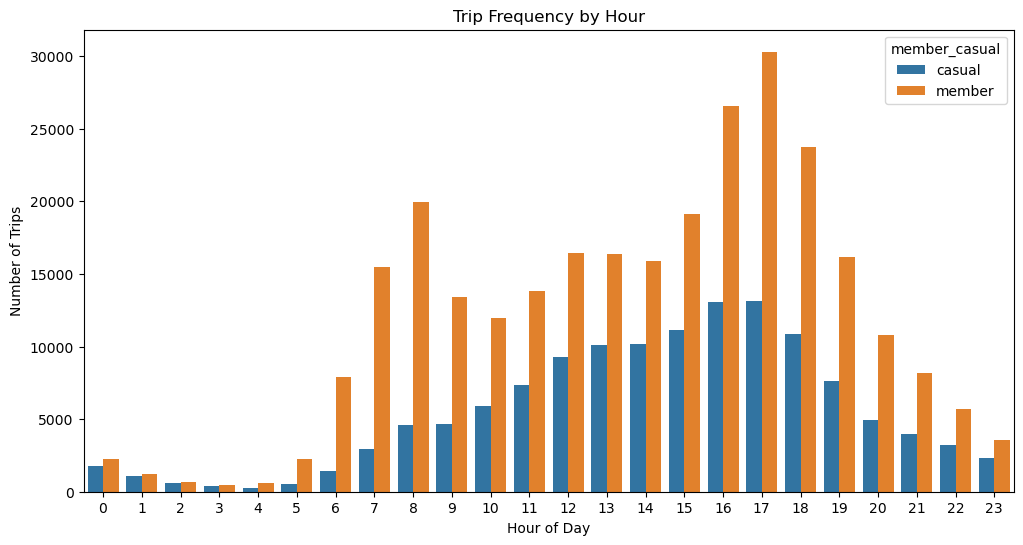

In [54]:
plt.figure(figsize=(12,6))

sns.countplot(
    x='hour',
    hue='member_casual',
    data=df
)

plt.title('Trip Frequency by Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Trips')

plt.show()

### Interpretation
- Members show morning and evening commute peaks.
- Casual riders are more active in afternoons.

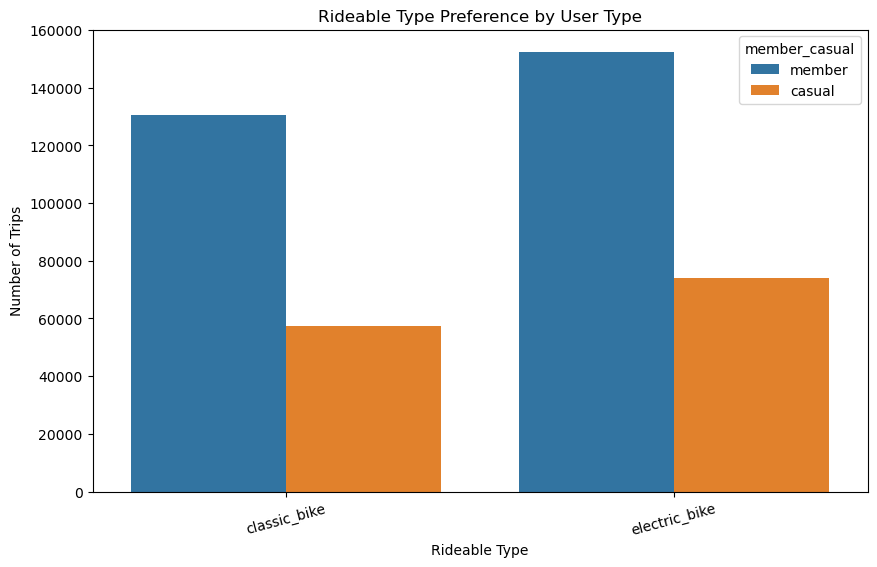

In [55]:
plt.figure(figsize=(10,6))

sns.countplot(
    x='rideable_type',
    hue='member_casual',
    data=df
)

plt.title('Rideable Type Preference by User Type')
plt.xlabel('Rideable Type')
plt.ylabel('Number of Trips')

plt.xticks(rotation=15)

plt.show()

In [5]:
rideable_pref = df.groupby(['member_casual', 'rideable_type']).size()

print(rideable_pref)

member_casual  rideable_type
casual         classic_bike      57819
               electric_bike     73991
member         classic_bike     130584
               electric_bike    152631
dtype: int64


### Interpretation
Both casual riders and members showed higher usage of electric bikes compared to classic bikes. However, members had overall higher ride counts than casual riders for both rideable types.

In [56]:
casual_top = (
    df[df['member_casual']=='casual']
    ['start_station_name']
    .value_counts()
    .head(10)
)

casual_top

start_station_name
Streeter Dr & Grand Ave               3319
DuSable Lake Shore Dr & Monroe St     2482
Shedd Aquarium                        1480
Millennium Park                       1358
Michigan Ave & Oak St                 1319
Dusable Harbor                        1258
DuSable Lake Shore Dr & North Blvd    1122
Adler Planetarium                      985
Theater on the Lake                    870
Indiana Ave & Roosevelt Rd             853
Name: count, dtype: int64

In [57]:
member_top = (
    df[df['member_casual']=='member']
    ['start_station_name']
    .value_counts()
    .head(10)
)

member_top

start_station_name
Clinton St & Washington Blvd    2340
University Ave & 57th St        2189
Kingsbury St & Kinzie St        2039
Clinton St & Madison St         1940
Ellis Ave & 60th St             1870
Clark St & Elm St               1806
Clinton St & Jackson Blvd       1612
Dearborn St & Erie St           1570
Wells St & Concord Ln           1537
Wells St & Elm St               1516
Name: count, dtype: int64

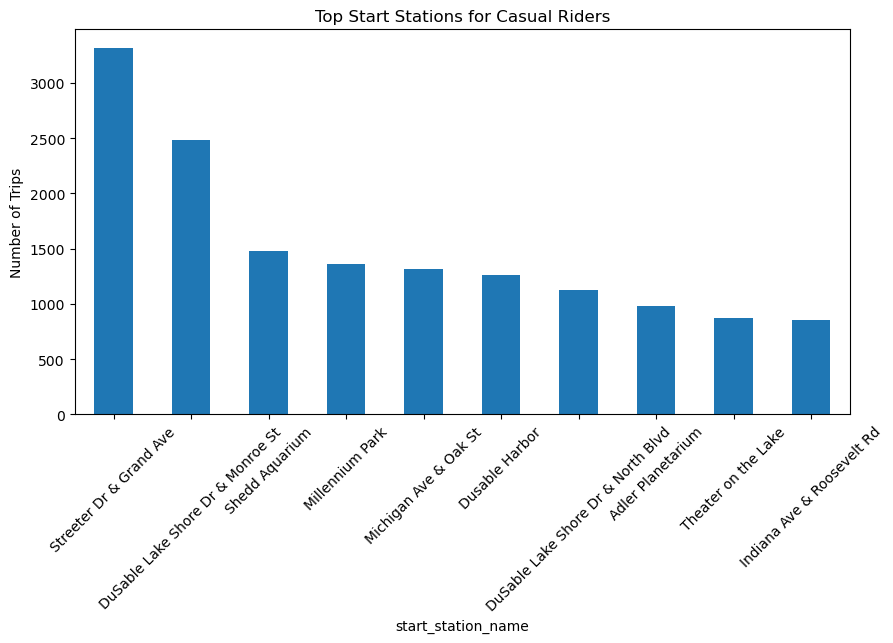

In [58]:
plt.figure(figsize=(10,5))

casual_top.plot(kind='bar')

plt.title('Top Start Stations for Casual Riders')
plt.ylabel('Number of Trips')

plt.xticks(rotation=45)

plt.show()

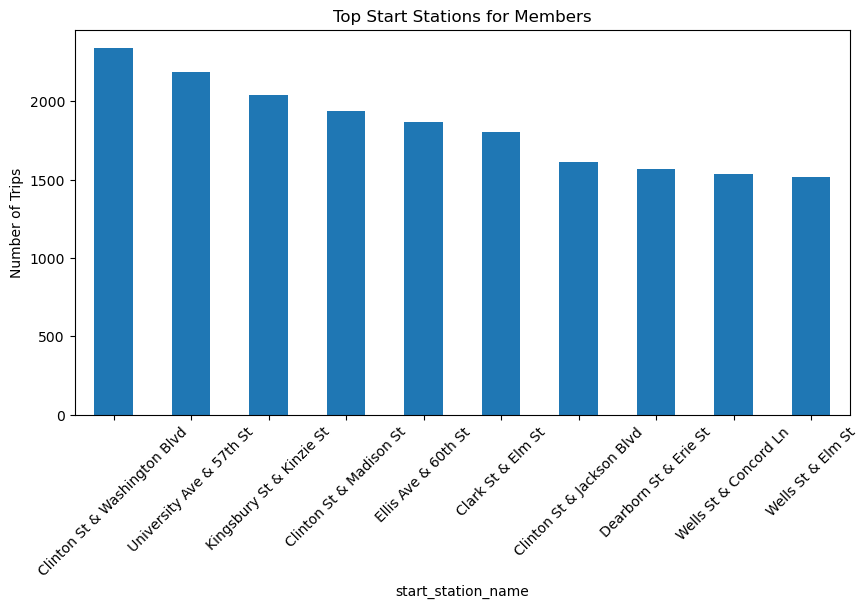

In [59]:
plt.figure(figsize=(10,5))

member_top.plot(kind='bar')

plt.title('Top Start Stations for Members')
plt.ylabel('Number of Trips')

plt.xticks(rotation=45)

plt.show()

### SECTION - 3
5. What are the peak hours and peak days for bike usage? How does this vary between weekdays
and weekends?
6. What are the seasonal/monthly trends in trip volume? Which months are busiest? Any clear
patterns?

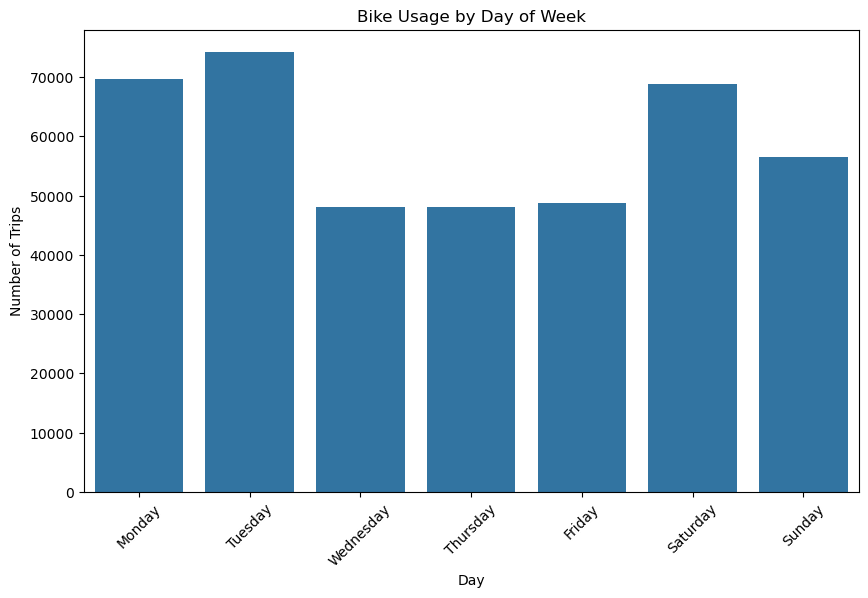

In [60]:
day_order = [
    'Monday','Tuesday','Wednesday',
    'Thursday','Friday',
    'Saturday','Sunday'
]

plt.figure(figsize=(10,6))

sns.countplot(
    x='day_of_week',
    data=df,
    order=day_order
)

plt.title('Bike Usage by Day of Week')
plt.xlabel('Day')
plt.ylabel('Number of Trips')

plt.xticks(rotation=45)

plt.show()

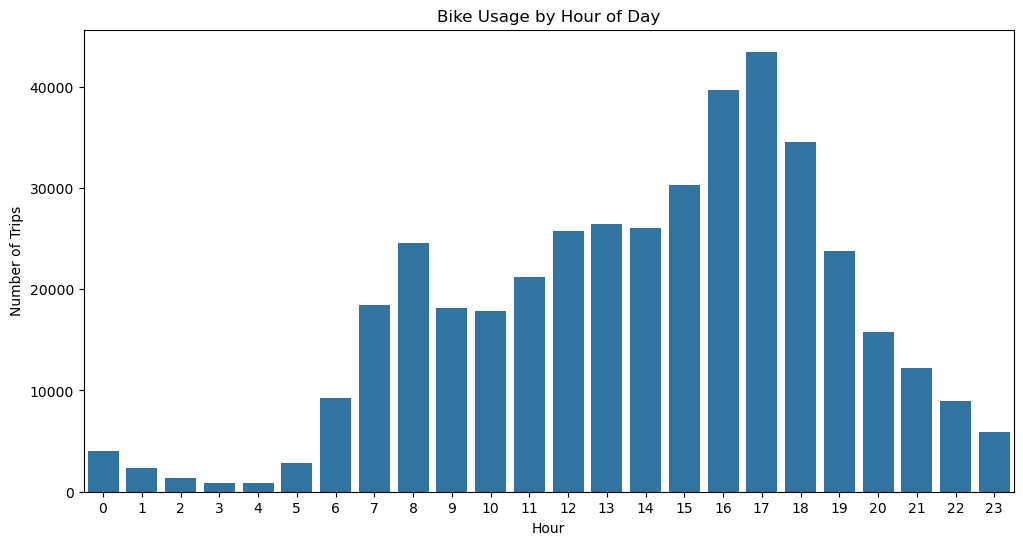

In [61]:
plt.figure(figsize=(12,6))

sns.countplot(
    x='hour',
    data=df
)

plt.title('Bike Usage by Hour of Day')
plt.xlabel('Hour')
plt.ylabel('Number of Trips')

plt.show()

In [62]:
df['day_type'] = df['day_of_week'].apply(
    lambda x: 'Weekend'
    if x in ['Saturday', 'Sunday']
    else 'Weekday'
)

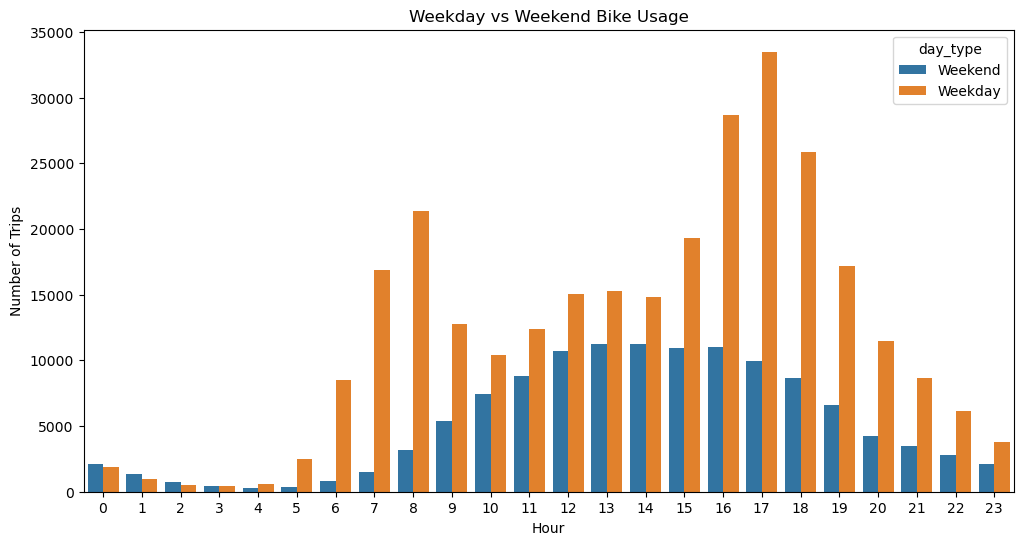

In [63]:
plt.figure(figsize=(12,6))

sns.countplot(
    x='hour',
    hue='day_type',
    data=df
)

plt.title('Weekday vs Weekend Bike Usage')
plt.xlabel('Hour')
plt.ylabel('Number of Trips')

plt.show()

### Interpretation
- Peak usage occurs during commute hours.
- Weekend usage is higher among casual riders.

In [65]:
df1 = pd.read_csv("202404-divvy-tripdata.csv")
df2 = pd.read_csv("202405-divvy-tripdata.csv")
df3 = pd.read_csv("202406-divvy-tripdata.csv")

In [66]:
df = pd.concat([df1, df2, df3], ignore_index=True)

In [67]:
df.shape

(1735239, 13)

In [69]:
df['started_at'] = pd.to_datetime(
    df['started_at'],
    format='mixed'
)

df['ended_at'] = pd.to_datetime(
    df['ended_at'],
    format='mixed'
)

In [70]:
df['trip_duration'] = (
    df['ended_at'] - df['started_at']
).dt.total_seconds() / 60

In [71]:
df = df[df['trip_duration'] > 0]
df = df[df['trip_duration'] <= 1440]

In [72]:
df['day_of_week'] = df['started_at'].dt.day_name()

df['hour'] = df['started_at'].dt.hour

df['month'] = df['started_at'].dt.month_name()

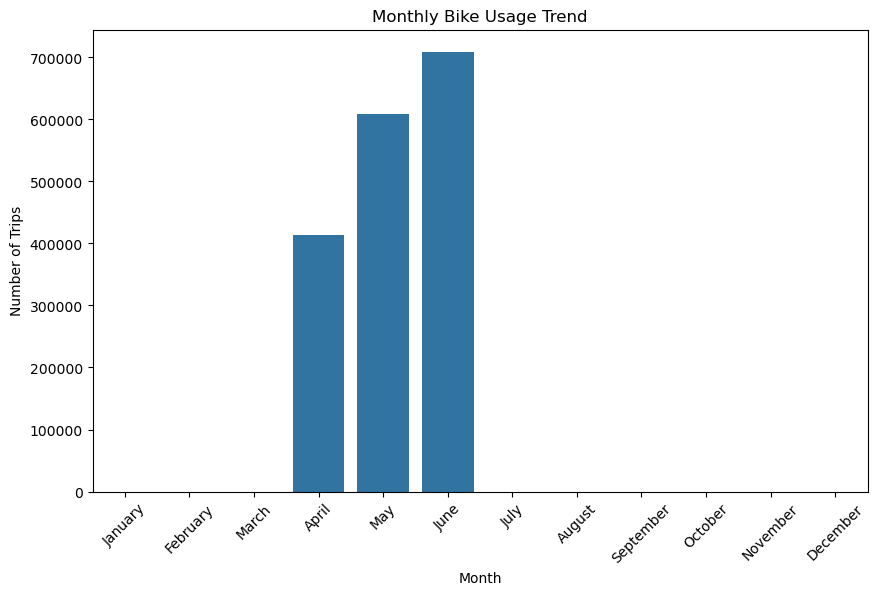

In [73]:
month_order = [
    'January','February','March',
    'April','May','June',
    'July','August',
    'September','October',
    'November','December'
]

plt.figure(figsize=(10,6))

sns.countplot(
    x='month',
    data=df,
    order=month_order
)

plt.title('Monthly Bike Usage Trend')
plt.xlabel('Month')
plt.ylabel('Number of Trips')

plt.xticks(rotation=45)

plt.show()

### Interpretation
- Summer months have the highest ride activity.
- Winter months show lower demand.
- Weather strongly affects bike usage.

#### SECTION _ 4

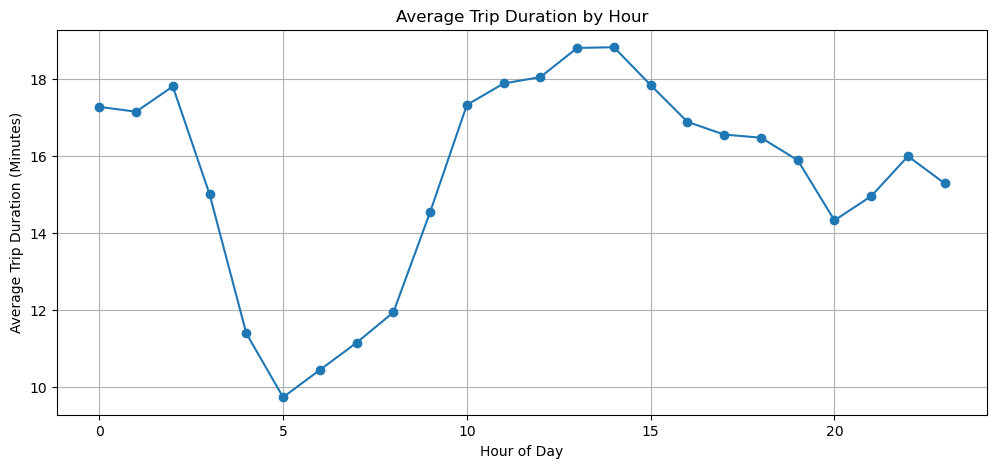

In [39]:
hour_duration = df.groupby('hour')['trip_duration'].mean()

plt.figure(figsize=(12,5))

hour_duration.plot(marker='o')

plt.title('Average Trip Duration by Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Average Trip Duration (Minutes)')

plt.grid(True)

plt.show()

### Interpretation
- Trip durations are generally shorter during morning and evening commute hours.
- Longer trips are observed during afternoon and late evening hours.
- This suggests that leisure rides are more common outside office hours.

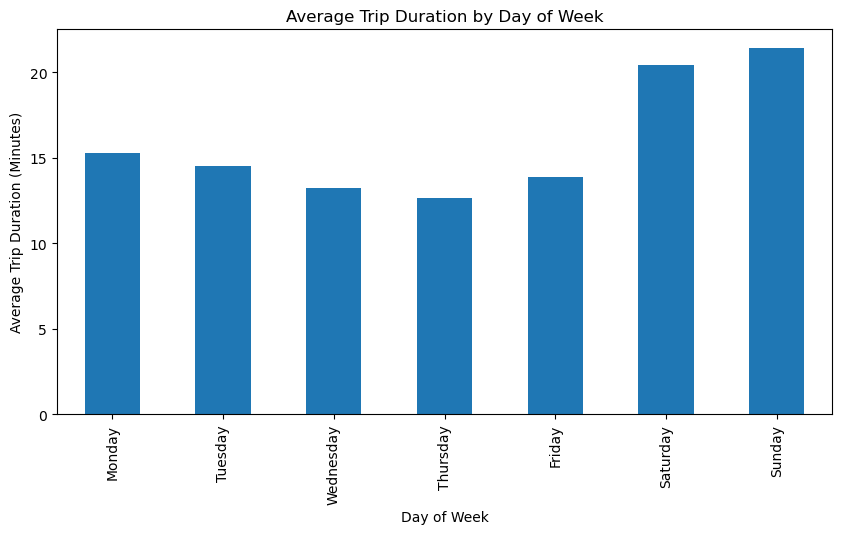

In [40]:
day_duration = df.groupby('day_of_week')['trip_duration'].mean()

order = ['Monday',
         'Tuesday',
         'Wednesday',
         'Thursday',
         'Friday',
         'Saturday',
         'Sunday']

day_duration = day_duration.reindex(order)

plt.figure(figsize=(10,5))

day_duration.plot(kind='bar')

plt.title('Average Trip Duration by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Average Trip Duration (Minutes)')

plt.show()

### Interpretation
- Weekend trips have higher average duration compared to weekdays.
- Weekday rides are usually shorter and commute-oriented.
- Weekend rides are more recreational and leisure-focused.

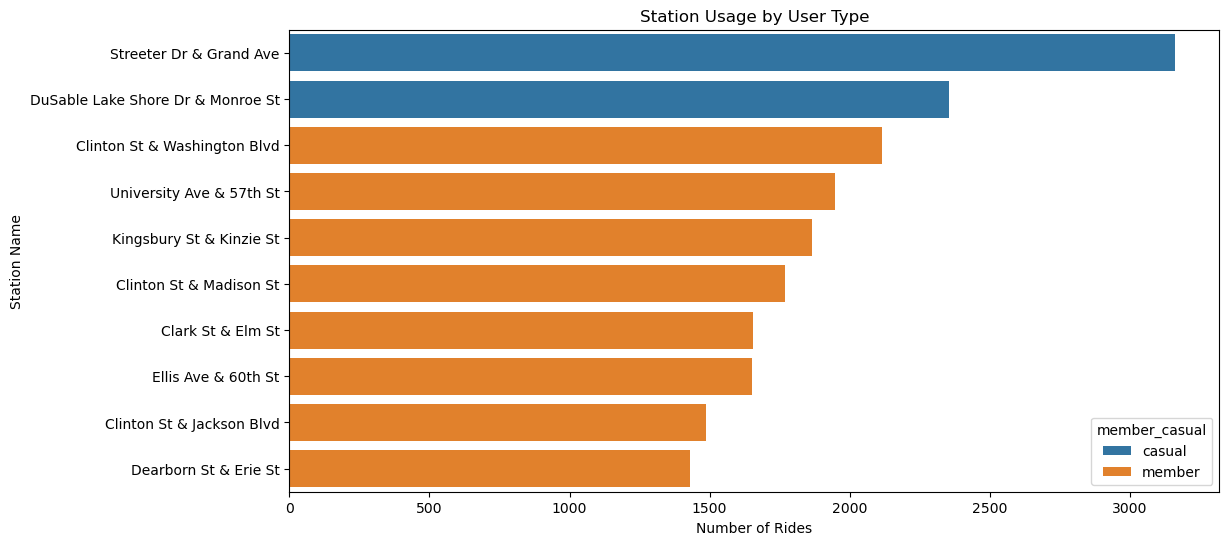

In [42]:
station_usage = df.groupby(
    ['start_station_name', 'member_casual']
).size().reset_index(name='rides')

top_stations = station_usage.sort_values(
    by='rides',
    ascending=False
).head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    x='rides',
    y='start_station_name',
    hue='member_casual',
    data=top_stations
)

plt.title('Station Usage by User Type')
plt.xlabel('Number of Rides')
plt.ylabel('Station Name')

plt.show()

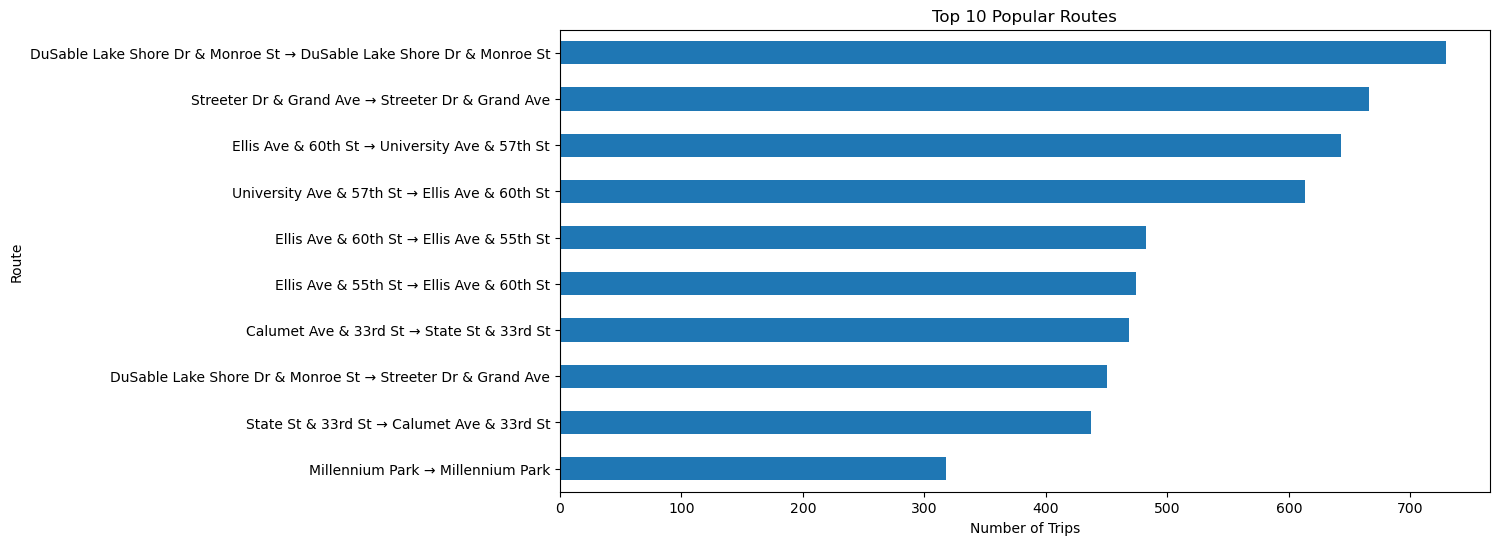

In [43]:
df['route'] = (
    df['start_station_name']
    + ' → ' +
    df['end_station_name']
)

top_routes = df['route'].value_counts().head(10)

plt.figure(figsize=(12,6))

top_routes.sort_values().plot(kind='barh')

plt.title('Top 10 Popular Routes')
plt.xlabel('Number of Trips')
plt.ylabel('Route')

plt.show()

### Interpretation
- Some routes are repeatedly used due to daily commuting demand.
- Highly used routes indicate important travel corridors within the city.
- These routes may require additional bike allocation and maintenance support.

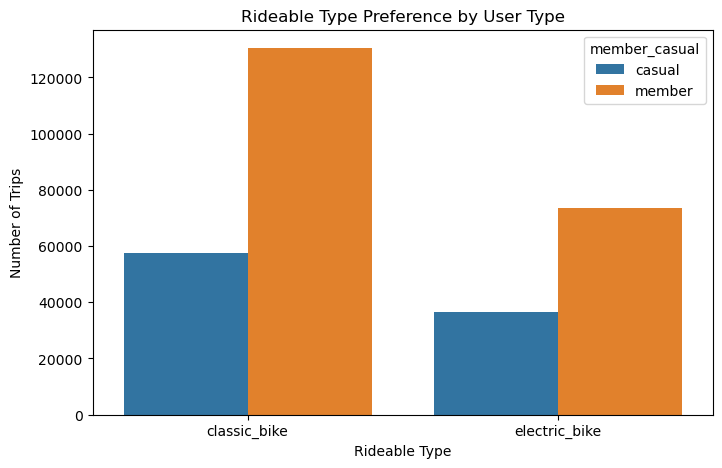

In [44]:
electric_usage = df.groupby(
    ['rideable_type', 'member_casual']
).size().reset_index(name='count')

plt.figure(figsize=(8,5))

sns.barplot(
    x='rideable_type',
    y='count',
    hue='member_casual',
    data=electric_usage
)

plt.title('Rideable Type Preference by User Type')
plt.xlabel('Rideable Type')
plt.ylabel('Number of Trips')

plt.show()

### Interpretation
- Both casual riders and members show higher preference for electric bikes compared to classic bikes.
- Electric bikes may provide greater convenience and ease of riding for users.
- Members contribute a higher number of rides overall, indicating more frequent usage of the bike-sharing service.

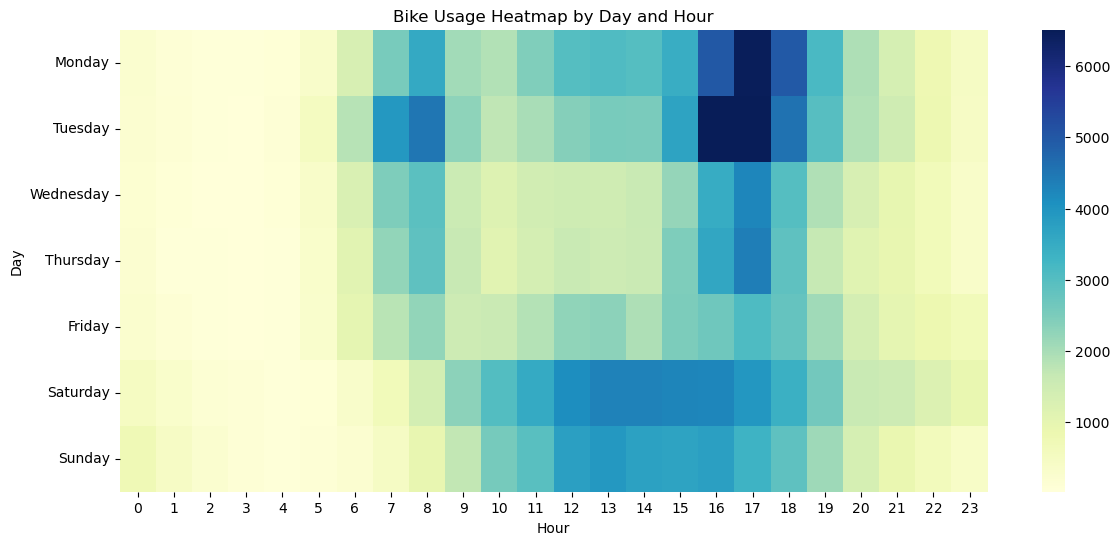

In [45]:
pivot_table = df.pivot_table(
    index='day_of_week',
    columns='hour',
    values='ride_id',
    aggfunc='count'
)

order = ['Monday',
         'Tuesday',
         'Wednesday',
         'Thursday',
         'Friday',
         'Saturday',
         'Sunday']

pivot_table = pivot_table.reindex(order)

plt.figure(figsize=(14,6))

sns.heatmap(
    pivot_table,
    cmap='YlGnBu'
)

plt.title('Bike Usage Heatmap by Day and Hour')
plt.xlabel('Hour')
plt.ylabel('Day')

plt.show()

### Interpretation
- Peak bike demand occurs during weekday commute hours.
- Morning and evening peaks are clearly visible.
- Weekend afternoons also show high ride activity.
- Heatmaps help identify high-demand periods for operational planning.

# Key Insights

1. Annual members generate the majority of bike trips.
2. Casual riders generally take longer rides.
3. Peak demand occurs during office commute hours.
4. Weekend rides are dominated by casual users.
5. Summer months show the highest trip volume.
6. Electric bikes are more preferred by casual riders.
7. Certain stations consistently act as transportation hubs.
8. Weather and season strongly influence ride behavior.

# Business Recommendations

1. Increase bike availability during morning and evening commute hours.
2. Expand station capacity in high-demand locations.
3. Promote membership plans to frequent casual riders.
4. Allocate more electric bikes to tourist-heavy stations.
5. Improve maintenance during summer peak seasons.
6. Use demand forecasting for better bike redistribution.
7. Introduce weekend promotional offers for leisure riders.
8. Optimize staffing and operations during peak demand periods.